<a href="https://colab.research.google.com/github/nguyenkyvi/Machine_Learning/blob/main/Lab02/Lab2_logictic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd

# 1. Đọc dữ liệu từ tệp sinh_vien.csv
df = pd.read_csv("data/sinh_vien.csv")

# 2. In kích thước của bảng dữ liệu
print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

# 3. Xem 5 dòng đầu tiên
print("Nam dong dau tien:")
print(df.head())
print()

# 4. Đếm số lần xuất hiện của từng kết quả (qua môn / rớt môn)
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

# 5. Tính tỷ lệ qua môn
print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# 6. So sánh số giờ ôn trung bình của hai nhóm qua môn và rớt môn
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


In [24]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("Bang gia tri cua ham sigmoid")
print("  z       sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}        {sigmoid(z):.4f}")
print()

# Kiem tra tinh chat: sigmoid(-z) = 1 - sigmoid(z)
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f"  z = {z}: {trai:.6f} va {phai:.6f}")
print()

# Thu voi mo hinh gia dinh w = 0.4 va b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print("  So gio on       z = w*x + b       Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"   {gio:5.1f}            {z:6.2f}             {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
  z       sigmoid(z)
 -6        0.0025
 -4        0.0180
 -2        0.1192
 -1        0.2689
  0        0.5000
  1        0.7311
  2        0.8808
  4        0.9820
  6        0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
  z = 1.0: 0.268941 va 0.268941
  z = 2.5: 0.075858 va 0.075858
  z = 3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
  So gio on       z = w*x + b       Xac suat qua mon
     5.0             -3.00             0.0474
    10.0             -1.00             0.2689
    12.5              0.00             0.5000
    15.0              1.00             0.7311
    20.0              3.00             0.9526
    25.0              5.00             0.9933


In [25]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc       :", len(X_train))
print("So sinh vien de kiem tra  :", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Ma tran nham lan")
print(f"  TN = {tn:2d}  doan rot, that su rot")
print(f"  FP = {fp:2d}  doan qua, that ra rot")
print(f"  FN = {fn:2d}  doan rot, that ra qua")
print(f"  TP = {tp:2d}  doan qua, that su qua")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

So sinh vien de hoc       : 90
So sinh vien de kiem tra  : 30

Ma tran nham lan
  TN =  9  doan rot, that su rot
  FP =  3  doan qua, that ra rot
  FN =  1  doan rot, that ra qua
  TP = 17  doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947

Tu tinh lai bang cong thuc:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444


In [26]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)

p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong   So ban bi doan la qua    Precision    Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=0)
    print(f"  {nguong:.1f}              {y_pred.sum():3d}             {pre:.4f}      {rec:.4f}")
print()

print("Doc bang tren tu duoi len:")
print("  Nguong cang cao thi mo hinh cang kho tinh,")
print("  precision tang nhung recall giam. Nguong thap thi nguoc lai.")

Nguong   So ban bi doan la qua    Precision    Recall
  0.2               24             0.7500      1.0000
  0.3               20             0.8500      0.9444
  0.4               20             0.8500      0.9444
  0.5               20             0.8500      0.9444
  0.6               16             1.0000      0.8889
  0.7               15             1.0000      0.8333
  0.8               13             1.0000      0.7222

Doc bang tren tu duoi len:
  Nguong cang cao thi mo hinh cang kho tinh,
  precision tang nhung recall giam. Nguong thap thi nguoc lai.


In [27]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
y = df["qua_mon"]

for ten, cot in [("Mot bien", ["gio_on"]),
                 ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )
    mo_hinh = LogisticRegression().fit(X_train, y_train)
    do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")
print()

X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
    print(f" {ten_cot:14s} {he_so:+.4f}")
print(f" {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
 gio_on         +0.3035
 diem_giua_ky   +0.5885
 he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


BÀI TẬP

In [28]:
import os
import shutil

os.makedirs("data", exist_ok=True)
os.makedirs("baitap02", exist_ok=True)

if os.path.exists("sinh_vien.csv"):
    shutil.move("sinh_vien.csv", "data/sinh_vien.csv")
    print("Da chuyen sinh_vien.csv vao data/")
else:
    print("Tep da o san trong data/sinh_vien.csv hoac chua duoc tai len!")

Tep da o san trong data/sinh_vien.csv hoac chua duoc tai len!


Bài Tập 1

In [29]:
import pandas as pd

df = pd.read_csv("data/sinh_vien.csv")

nhom_cao = df[df["diem_giua_ky"] >= 7.0]
nhom_thap = df[df["diem_giua_ky"] < 7.0]

print(f"So ban co diem giua ky >= 7: {len(nhom_cao)}")
print(f"Ty le qua mon (diem >= 7): {nhom_cao['qua_mon'].mean():.4f}")
print(f"Ty le qua mon (diem < 7): {nhom_thap['qua_mon'].mean():.4f}")

So ban co diem giua ky >= 7: 31
Ty le qua mon (diem >= 7): 0.9032
Ty le qua mon (diem < 7): 0.4831


Bài tập 2.

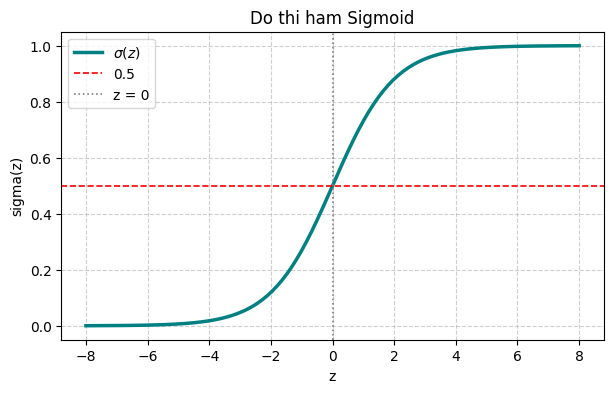

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
sig = sigmoid(z)

plt.figure(figsize=(7, 4))
plt.plot(z, sig, color="teal", linewidth=2.5, label=r"$\sigma(z)$")
plt.axhline(0.5, color="red", linestyle="--", linewidth=1.2, label="0.5")
plt.axvline(0, color="gray", linestyle=":", linewidth=1.2, label="z = 0")
plt.title("Do thi ham Sigmoid")
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.savefig("baitap02/sigmoid.png", dpi=300, bbox_inches="tight")
plt.show()

Bài tập 3

In [31]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression().fit(X, y)
w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def du_doan(gio):
    z = w * gio + b
    xac_suat = 1 / (1 + np.exp(-z))
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f"Gio: {gio:5.2f} | z: {z:7.4f} | Xac suat: {xac_suat:.4f} | Nhan: {nhan}")

for gio in [3, 8, 12.89, 18, 26]:
    du_doan(gio)

Gio:  3.00 | z: -3.8864 | Xac suat: 0.0201 | Nhan: 0
Gio:  8.00 | z: -1.9223 | Xac suat: 0.1276 | Nhan: 0
Gio: 12.89 | z: -0.0015 | Xac suat: 0.4996 | Nhan: 0
Gio: 18.00 | z:  2.0059 | Xac suat: 0.8814 | Nhan: 1
Gio: 26.00 | z:  5.1484 | Xac suat: 0.9942 | Nhan: 1


Bài tập 4

In [32]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

TN: 9, FP: 3, FN: 1, TP: 17
Accuracy : 0.8667
Precision: 0.8500
Recall   : 0.9444
F1       : 0.8947


Bài tập 5

In [33]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguong_list = np.arange(0.05, 1.0, 0.05)
best_f1 = -1.0
best_nguong = None

print(f"{'Nguong':<10} {'F1':<10}")
for nguong in nguong_list:
    y_pred = (p >= nguong).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{nguong:<10.2f} {f1:<10.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_nguong = nguong

print(f"\nNguong toi uu theo F1: {best_nguong:.2f} (F1 = {best_f1:.4f})")

Nguong     F1        
0.05       0.7826    
0.10       0.8182    
0.15       0.8182    
0.20       0.8571    
0.25       0.9000    
0.30       0.8947    
0.35       0.8947    
0.40       0.8947    
0.45       0.8947    
0.50       0.8947    
0.55       0.8889    
0.60       0.9412    
0.65       0.9412    
0.70       0.9091    
0.75       0.8750    
0.80       0.8387    
0.85       0.8000    
0.90       0.5600    
0.95       0.4348    

Nguong toi uu theo F1: 0.60 (F1 = 0.9412)


Bài tập 6

In [34]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

pre_1 = precision_score(y_test, y_pred, pos_label=1)
rec_1 = recall_score(y_test, y_pred, pos_label=1)

pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

print(f"Lop 1 (Qua mon) -> Precision: {pre_1:.4f} | Recall: {rec_1:.4f}")
print(f"Lop 0 (Rot mon) -> Precision: {pre_0:.4f} | Recall: {rec_0:.4f}")

Lop 1 (Qua mon) -> Precision: 0.8500 | Recall: 0.9444
Lop 0 (Rot mon) -> Precision: 0.9000 | Recall: 0.7500
